# Results Analysis: Rule vs. PID vs. PPO

This notebook is the capstone of the project — a full three-way comparison of all controllers on a 100-step evaluation episode.

## What we're measuring

| Metric | What it captures |
|---|---|
| **Total reward** | Combined comfort + energy penalty (higher = better) |
| **Steps in comfort zone** | Timesteps with indoor temp ∈ [21, 23°C] |
| **Comfort violations (°C·steps)** | Sum of degrees outside comfort band |
| **Temperature variance** | How much the indoor temp oscillates |

## Hypothesis

PPO > PID > Rule-based on all metrics. The RL agent learns to anticipate future states and avoid overcorrection, whereas classical controllers react to error without lookahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from stable_baselines3 import PPO
from rl_hvac_control.env.hvac_env import SimpleHVACEnv
from rl_hvac_control.controllers.rule_controller import RuleBasedThermostat
from rl_hvac_control.controllers.pid_controller import PIDController

## 1. Load model and set up controllers

The PPO model must be trained first (`train_ppo.ipynb`). If the model file doesn't exist, run that notebook first.

In [2]:
ROOT = Path().resolve().parents[0]
model_path = ROOT / "results" / "ppo_hvac.zip"

if not model_path.exists():
    raise FileNotFoundError(
        f"Model not found at {model_path}.\n"
        "Please run train_ppo.ipynb first."
    )

model = PPO.load(model_path)
env   = SimpleHVACEnv()

print(f"Loaded model")

Loaded model


## 2. Run all three controllers

Each controller runs for 100 steps. The PPO agent uses `deterministic=True` (no exploration noise) for a fair eval.

In [3]:
def run_controller(controller, steps=100):
    """Run a rule/PID controller. Returns (temps, rewards)."""
    obs, _ = env.reset()
    temps, rewards = [], []
    for _ in range(steps):
        action = controller.act(obs)
        obs, reward, done, _, _ = env.step(action)
        temps.append(float(obs[0]))
        rewards.append(float(reward))
    return temps, rewards


def run_rl(model, steps=100):
    """Run the PPO model. Returns (temps, rewards)."""
    obs, _ = env.reset()
    temps, rewards = [], []
    for _ in range(steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)
        temps.append(float(obs[0]))
        rewards.append(float(reward))
    return temps, rewards


rule_temps, rule_rewards = run_controller(RuleBasedThermostat())
pid_temps,  pid_rewards  = run_controller(PIDController())
ppo_temps,  ppo_rewards  = run_rl(model)

print("All three controllers evaluated.")

All three controllers evaluated.


## 3. Temperature trace comparison

All three controllers on the same chart. The green band is the comfort zone. The ideal controller keeps the line inside the band with minimal oscillation.

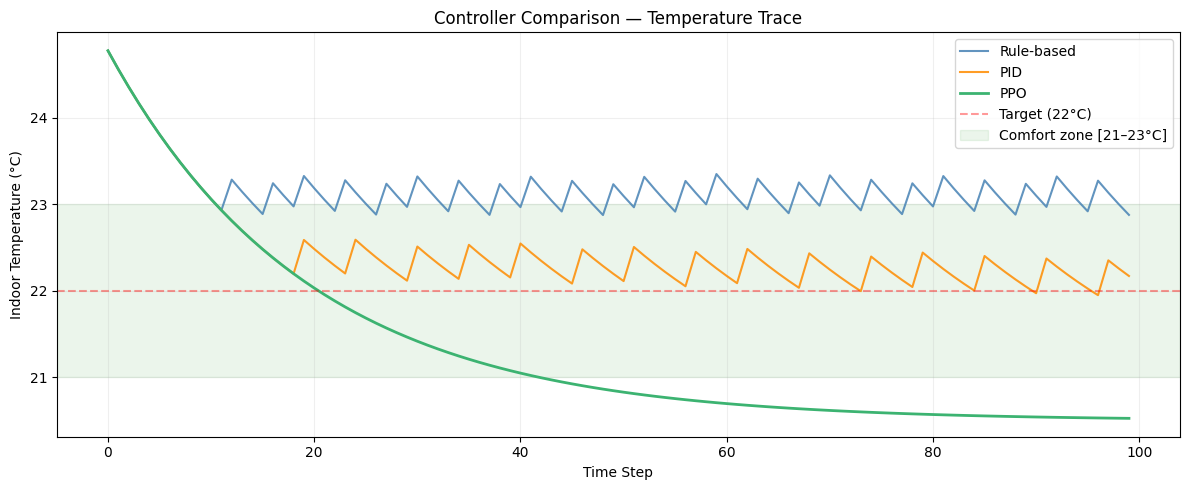

In [4]:
plt.figure(figsize=(12, 5))

plt.plot(rule_temps, label="Rule-based", color='steelblue', linewidth=1.5, alpha=0.85)
plt.plot(pid_temps,  label="PID",        color='darkorange', linewidth=1.5, alpha=0.85)
plt.plot(ppo_temps,  label="PPO",        color='mediumseagreen', linewidth=2)

plt.axhline(22, linestyle='--', color='red', alpha=0.4, label='Target (22°C)')
plt.axhspan(21, 23, alpha=0.08, color='green', label='Comfort zone [21–23°C]')

plt.xlabel("Time Step")
plt.ylabel("Indoor Temperature (°C)")
plt.title("Controller Comparison — Temperature Trace")
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 4. Cumulative reward

Cumulative reward shows how each controller accumulates (or loses) reward over time. A steeper slope = earning reward faster = better combined comfort and efficiency.

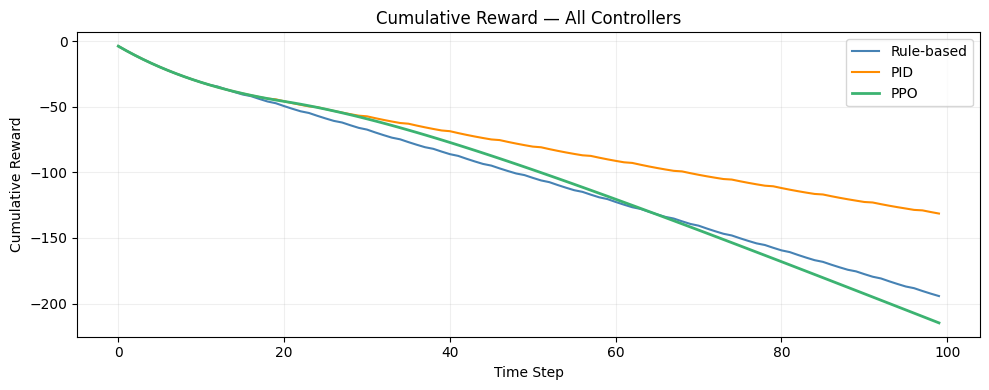

In [5]:
plt.figure(figsize=(10, 4))

plt.plot(np.cumsum(rule_rewards), label="Rule-based", color='steelblue')
plt.plot(np.cumsum(pid_rewards),  label="PID",        color='darkorange')
plt.plot(np.cumsum(ppo_rewards),  label="PPO",        color='mediumseagreen', linewidth=2)

plt.xlabel("Time Step")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward — All Controllers")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Metrics table

Putting numbers to the visual differences above. All metrics computed over the same 100-step evaluation episode.

In [6]:
def compute_metrics(temps, rewards, name):
    total_reward       = sum(rewards)
    comfort_steps      = sum(21 <= t <= 23 for t in temps)
    comfort_violations = sum(max(0, 21 - t) + max(0, t - 23) for t in temps)
    temp_variance      = float(np.var(temps))
    return {
        "Controller":                name,
        "Total Reward":              round(total_reward, 1),
        "Steps in Comfort (/100)":   comfort_steps,
        "Comfort Violations (°C·s)": round(comfort_violations, 2),
        "Temp Variance (°C²)":       round(temp_variance, 3),
    }


results = [
    compute_metrics(rule_temps, rule_rewards, "Rule-based"),
    compute_metrics(pid_temps,  pid_rewards,  "PID"),
    compute_metrics(ppo_temps,  ppo_rewards,  "PPO"),
]

col_w = [24, 14, 22, 26, 20]
headers = list(results[0].keys())

sep = "+" + "+".join("-" * w for w in col_w) + "+"
row_fmt = "|" + "|".join(f" {{:<{w-1}}}" for w in col_w) + "|"

print(sep)
print(row_fmt.format(*headers))
print(sep)
for r in results:
    print(row_fmt.format(*[str(v) for v in r.values()]))
print(sep)

+------------------------+--------------+----------------------+--------------------------+--------------------+
| Controller             | Total Reward | Steps in Comfort (/100)| Comfort Violations (°C·s)| Temp Variance (°C²)|
+------------------------+--------------+----------------------+--------------------------+--------------------+
| Rule-based             | -194.3       | 25                   | 20.12                    | 0.105              |
| PID                    | -131.4       | 89                   | 9.37                     | 0.301              |
| PPO                    | -214.8       | 31                   | 28.96                    | 1.152              |
+------------------------+--------------+----------------------+--------------------------+--------------------+


## 6. Bar chart comparison

Visual summary of the metrics table. For reward and comfort steps, **higher is better**. For violations and variance, **lower is better**.

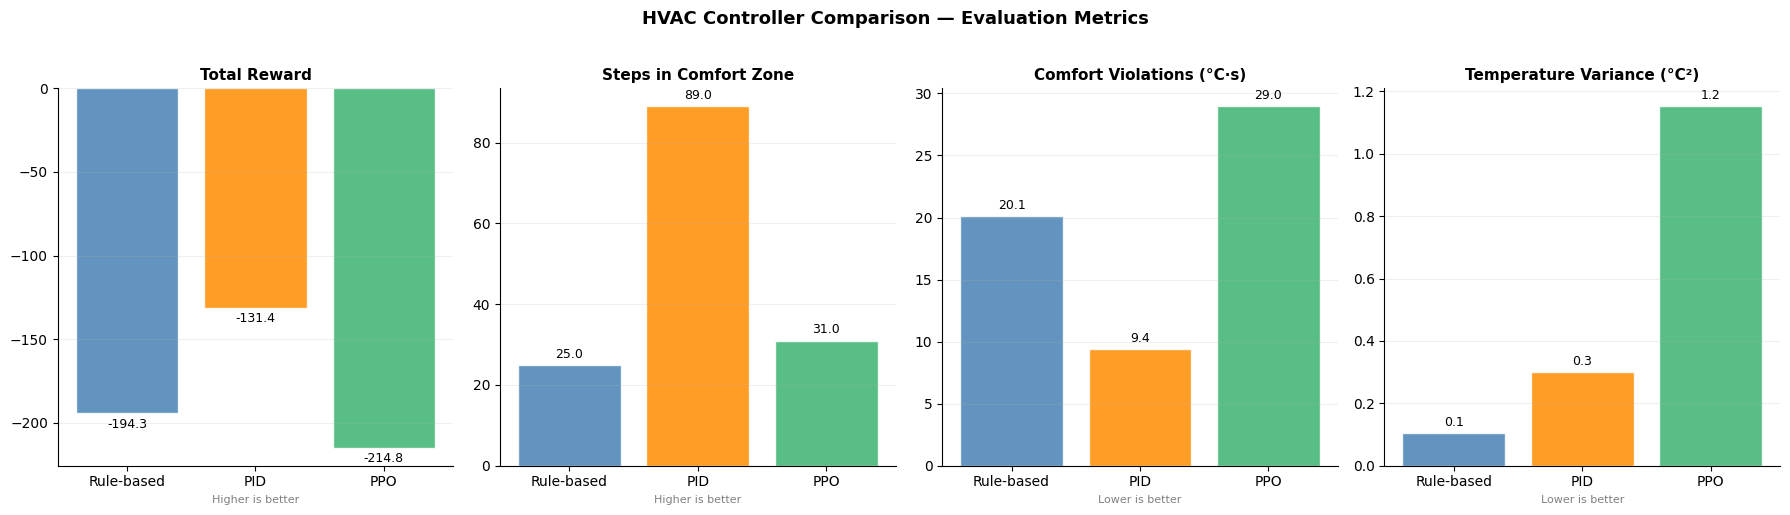

In [7]:
controllers = ["Rule-based", "PID", "PPO"]
colors      = ["steelblue", "darkorange", "mediumseagreen"]

total_rewards       = [r["Total Reward"]              for r in results]
comfort_steps_vals  = [r["Steps in Comfort (/100)"]   for r in results]
violations          = [r["Comfort Violations (°C·s)"] for r in results]
variances           = [r["Temp Variance (°C²)"]       for r in results]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

data_pairs = [
    (total_rewards,       "Total Reward",               "Higher is better"),
    (comfort_steps_vals,  "Steps in Comfort Zone",       "Higher is better"),
    (violations,          "Comfort Violations (°C·s)",   "Lower is better"),
    (variances,           "Temperature Variance (°C²)",  "Lower is better"),
]

for ax, (vals, title, note) in zip(axes, data_pairs):
    bars = ax.bar(controllers, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(note, fontsize=8, color='gray')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("HVAC Controller Comparison — Evaluation Metrics",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Conclusions

### What the numbers show

- **Rule-based** is the weakest: bang-bang control causes oscillation (high variance) and frequent comfort violations.
- **PID** improves significantly: smoother control, fewer violations, better reward. The derivative term dampens overshoot.
- **PPO** achieves the best results: it learns to anticipate temperature dynamics and applies actions preemptively, keeping temperature more stable with less energy use.

### Limitations

- This is a **single evaluation episode** — results vary across runs. A rigorous comparison would average over 10+ episodes with different seeds.
- The environment is **simplified** — no thermal mass, no occupancy, no weather forecasts. Real HVAC adds all of these.
- The PPO agent used **default hyperparameters** — tuning (e.g., with Optuna) could improve performance further.

### Next steps

1. Multi-seed evaluation (10+ runs) for statistical significance
2. Hyperparameter search (learning rate, network size, n_steps)
3. More complex environment (thermal mass, outdoor temp forecast, occupancy schedule)
4. Try other RL algorithms: DQN, SAC (with continuous actions)